In [1]:
from statistics import median

import requests
import pandas as pd
import numpy as np
import time as t
import seaborn as sns
import matplotlib.pyplot as plt
from mysql.connector import cursor

In [14]:
KEYWORDS = ["Smart Phone", "Tv", "Ac", "Camera", "Washing Machine",
            "Earbuds", "Speaker", "Laptop", "Tablet", "Watch"]

api_key = "MY_KEY"
url = "https://serpapi.com/search"
all_products = []

for k in KEYWORDS:
    print(f"\nSearching: {k}")
    k_count = 0
    start = 0
    while k_count < 120:
        params = {
            "engine": "google_shopping",
            "q": k,
            "gl": "in",
            "api_key": api_key,
            "start": start
        }
        response = requests.get(url, params=params)
        data = response.json()

        if "error" in data:
            print(f"API error for '{k}': {data['error']}")
            break

        results = data.get("shopping_results", [])
        if not results:
            print(f"No more results at start={start}")
            break

        for i in results:
            all_products.append({
                "keyword": k,
                "title": i.get("title"),
                "price": i.get("extracted_price"),
                "raw_price": i.get("price"),
                "rating": i.get("rating"),
                "reviews": i.get("reviews"),
                "platform": i.get("source"),
                "position": i.get("position"),
                "delivery": i.get("delivery"),
                "link": i.get("link"),
                "thumbnail": i.get("thumbnail")
            })

        k_count += len(results)
        start += len(results)
        t.sleep(1)

    print(f"{k} result collected: {k_count} rows")

df = pd.DataFrame(all_products)
print(df.shape)
print(df.head())


Searching: Smart Phone
Smart Phone result collected: 120 rows

Searching: Tv
Tv result collected: 120 rows

Searching: Ac
Ac result collected: 120 rows

Searching: Camera
Camera result collected: 120 rows

Searching: Washing Machine
Washing Machine result collected: 120 rows

Searching: Earbuds
Earbuds result collected: 120 rows

Searching: Speaker
Speaker result collected: 120 rows

Searching: Laptop
Laptop result collected: 120 rows

Searching: Tablet
Tablet result collected: 120 rows

Searching: Watch
Watch result collected: 120 rows
(1200, 11)
       keyword                          title     price  raw_price  rating  \
0  Smart Phone       Vivo Y31 5G Mobile Phone   27999.0    ₹27,999     4.6   
1  Smart Phone       OnePlus N6 5G Smartphone   26999.0    ₹26,999     NaN   
2  Smart Phone            Apple iPhone 17 Pro  134900.0  ₹1,34,900     4.6   
3  Smart Phone    Samsung Galaxy S25 Ultra 5G  129999.0  ₹1,29,999     4.8   
4  Smart Phone  Google Pixel 7a 5G Smartphone   28499.0

In [ ]:
df.to_csv("Product_Result.csv", index=False)

In [ ]:
#=============================================== (Cleaning 1st dataset) ============================================================

In [9]:
Shopping_df = pd.read_csv("Product_Result.csv")
Shopping_df.head(3)

,keyword,title,price,raw_price,rating,reviews,platform,position,delivery,link,thumbnail
0,Smart Phone,Vivo Y31 5G Mobile Phone,27999.0,"₹27,999",4.6,89.0,Croma,1,NaN,NaN,https://encrypted-tbn1.gstatic.com/shopping?q=...
1,Smart Phone,OnePlus N6 5G Smartphone,26999.0,"₹26,999",NaN,NaN,Amazon.in,2,Free delivery,NaN,https://encrypted-tbn0.gstatic.com/shopping?q=...
2,Smart Phone,Apple iPhone 17 Pro,134900.0,"₹1,34,900",4.6,11000.0,Apple,3,Free delivery,NaN,https://encrypted-tbn1.gstatic.com/shopping?q=...


In [10]:
Shopping_df.dtypes

keyword          str
title            str
price        float64
raw_price        str
rating       float64
reviews      float64
platform         str
position       int64
delivery         str
link         float64
thumbnail        str
dtype: object

In [11]:
Shopping_df.isna().sum()

keyword         0
title           0
price           0
raw_price       0
rating        546
reviews       546
platform        0
position        0
delivery      121
link         1200
thumbnail       0
dtype: int64

In [12]:
Shopping_df.shape

(1200, 11)

In [13]:
Shopping_df=Shopping_df.drop(columns=["link","raw_price"])

In [15]:
for col in ["keyword","title","platform","delivery"]:
    if col in Shopping_df.columns:
        Shopping_df[col]=Shopping_df[col].astype(str).str.strip()

In [16]:
def clean_platform(p):
    p_lower=p.lower()
    if 'amazon' in p_lower:
        return "Amazon"
    if 'flipkart' in p_lower or 'shopsy' in p_lower:
        return "Flipkart"
    if 'samsung' in p_lower:
        return "Samsung"
    if 'apple' in p_lower:
        return "Apple"
    if 'mi.com' in p_lower:
        return "Mi.com"
    if 'reliance' in p_lower:
        return "Reliance"
    return p.title()

Shopping_df["clean_platform"]=Shopping_df["platform"].apply(clean_platform)

In [18]:
Shopping_df=Shopping_df[~((Shopping_df['keyword']=='Laptop') & (Shopping_df['price']<500))]

In [20]:
Shopping_df['delivery']=Shopping_df['delivery'].replace('nan',np.nan)
Shopping_df['clean_delivery']=Shopping_df['delivery'].fillna('Free Delivery')
Shopping_df['clean_delivery']=Shopping_df['clean_delivery'].str.replace('delivery','Delivery',case=False)

In [22]:
Shopping_df['clean_rating']=Shopping_df.groupby('title')['rating'].transform(lambda x: x.ffill().bfill())
Shopping_df['clean_reviews']=Shopping_df.groupby('title')['reviews'].transform((lambda x: x.ffill().bfill()))


Shopping_df['clean_rating']=Shopping_df.groupby('keyword')['clean_rating'].transform(lambda x: x.fillna(x.median()))
Shopping_df['clean_reviews']=Shopping_df.groupby('keyword')['clean_reviews'].transform(lambda x: x.fillna(x.median()))
Shopping_df['clean_reviews']=Shopping_df['clean_reviews'].round().astype(int)

In [27]:
duplicate_subset = ['keyword', 'title', 'price', 'clean_platform', 'clean_delivery']
Shopping_df_cleaned = Shopping_df.drop_duplicates(subset=duplicate_subset, keep='first').copy()

In [28]:
final_df = Shopping_df_cleaned[[
    'keyword',
    'title',
    'price',
    'clean_rating',
    'clean_reviews',
    'clean_platform',
    'clean_delivery',
    'thumbnail'  # 'brand' has been removed
]].rename(columns={
    'clean_rating': 'rating',
    'clean_reviews': 'reviews',
    'clean_platform': 'platform',
    'clean_delivery': 'delivery'
})

In [ ]:
final_df.to_csv("cleaned_product_result.csv", index=False)

============================================(Second Dataset)===============================================

In [8]:
# Loading the second dataset
Brand_df=pd.read_csv("brand_dirty_dataset.csv")

In [13]:
Brand_df.head(5)

,keyword,title,price,rating,reviews,platform,delivery
0,office chair ergonomic,HP office chair ergonomic Model 603,36225.0,3.7,3241,croma,2 Days
1,microwave oven convection,Samsung microwave oven convection Model 524 !!!,NaN,4.7,1294,amazon,Free Delivery
2,power bank fast charging,Samsung power bank fast charging Model 402,Not Available,NaN,3070,CROMA,Free Delivery
3,microwave oven convection,Dell microwave oven convection Model 877,2507.0,4.7,3446,flipkart,Free Delivery
4,men running shoes,Dell men running shoes Model 536,2176.0,3.8,2031,croma,5 Days


In [14]:
Brand_df.shape

(1320, 7)

In [15]:
Brand_df.isna().sum()

keyword       0
title         0
price       126
rating      131
reviews       0
platform      0
delivery      0
dtype: int64

In [16]:
Brand_df.dtypes

keyword         str
title           str
price           str
rating      float64
reviews         str
platform        str
delivery        str
dtype: object

In [18]:
NV=['Not Available','not available','N/A','NA','none','None','many']

# for Price
Brand_df['price']=Brand_df['price'].replace(NV,np.nan)
Brand_df['price']=pd.to_numeric(Brand_df['price'],errors='coerce')
Brand_df.loc[Brand_df['price']<0,'price']=0

# for rating
Brand_df['rating']=pd.to_numeric(Brand_df['rating'],errors='coerce')
Brand_df.loc[(Brand_df['rating']<0)|(Brand_df['rating']>5),'rating']=np.nan

# for reviews
Brand_df['reviews']=Brand_df['reviews'].replace(NV,np.nan)
Brand_df['reviews']=pd.to_numeric(Brand_df['reviews'],errors='coerce')

In [21]:
# for platform
Brand_df['platform']=Brand_df['platform'].str.strip().str.lower()

# for delivery
Brand_df['delivery']=Brand_df['delivery'].str.strip()

# for keyword
Brand_df['keyword']=Brand_df['keyword'].str.strip().str.lower()

# for title
Brand_df['title']=Brand_df['title'].replace(r"!+","",regex=True)
Brand_df['title']=Brand_df['title'].str.strip()
Brand_df['title']=Brand_df['title'].replace(r"\s+"," ",regex=True)

In [23]:
print(Brand_df[['platform','delivery','keyword','title']].head())

   platform       delivery                    keyword  \
0     croma         2 Days     office chair ergonomic   
1    amazon  Free Delivery  microwave oven convection   
2     croma  Free Delivery   power bank fast charging   
3  flipkart  Free Delivery  microwave oven convection   
4     croma         5 Days          men running shoes   

                                         title  
0          HP office chair ergonomic Model 603  
1  Samsung microwave oven convection Model 524  
2   Samsung power bank fast charging Model 402  
3     Dell microwave oven convection Model 877  
4             Dell men running shoes Model 536  


In [24]:
# remove duplicates

before=len(Brand_df)
Brand_df=Brand_df.drop_duplicates()
after=len(Brand_df)

print(f"{before-after}duplicate columns removes")

85duplicate columns removes


In [26]:
# Missing Values

Brand_df['price']=Brand_df.groupby('keyword')['price'].transform(lambda x: x.fillna(x.median()))
Brand_df['rating']=Brand_df.groupby('keyword')['rating'].transform(lambda x: x.fillna(x.median()))
Brand_df['reviews']=Brand_df.groupby('keyword')['reviews'].transform(lambda x: x.fillna(x.median()))


Brand_df['price']=Brand_df['price'].fillna(Brand_df['price'].median())
Brand_df['rating']=Brand_df['rating'].fillna(Brand_df['rating'].median())
Brand_df['reviews']=Brand_df['reviews'].fillna(Brand_df['reviews'].median())

In [27]:
print(Brand_df[['price','rating','reviews']].isna().sum())

price      0
rating     0
reviews    0
dtype: int64


In [28]:
# handling Outliers

q1=Brand_df.groupby('keyword')['price'].transform(lambda x: x.quantile(0.25))
q3=Brand_df.groupby('keyword')['price'].transform(lambda x: x.quantile(0.75))

iqr=q3-q1

lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr

Brand_df['price']=Brand_df['price'].clip(lower=lower_bound,upper=upper_bound)

In [29]:
print(Brand_df.groupby("keyword")["price"].describe())

                           count          mean           std  min       25%  \
keyword                                                                       
air fryer india            244.0  24768.377049  14418.865322  0.0  14871.75   
men running shoes          245.0  23670.640816  14753.285549  0.0  12377.00   
microwave oven convection  262.0  25479.167939  17793.685350  0.0  12265.25   
office chair ergonomic     241.0  26744.477178  18141.183903  0.0  12081.00   
power bank fast charging   243.0  26957.539095  15554.838743  0.0  14769.00   

                               50%       75%        max  
keyword                                                  
air fryer india            23754.5  33830.00  62267.375  
men running shoes          22136.0  32059.00  61582.000  
microwave oven convection  23503.0  36602.75  73109.000  
office chair ergonomic     24626.0  39692.00  81108.500  
power bank fast charging   26802.0  36759.00  69744.000  


In [30]:
# round up all the things

Brand_df['price']=Brand_df['price'].round(2)
Brand_df['reviews']=Brand_df['reviews'].round().astype(int)
Brand_df['rating']=Brand_df['rating'].round(1)


In [31]:
## Final check
Brand_df.shape

(1235, 7)

In [32]:
Brand_df.isna().sum()

keyword     0
title       0
price       0
rating      0
reviews     0
platform    0
delivery    0
dtype: int64

In [33]:
Brand_df.dtypes

keyword         str
title           str
price       float64
rating      float64
reviews       int64
platform        str
delivery        str
dtype: object

In [34]:
Brand_df.head(3)

,keyword,title,price,rating,reviews,platform,delivery
0,office chair ergonomic,HP office chair ergonomic Model 603,36225.0,3.7,3241,croma,2 Days
1,microwave oven convection,Samsung microwave oven convection Model 524,23503.0,4.7,1294,amazon,Free Delivery
2,power bank fast charging,Samsung power bank fast charging Model 402,26802.0,3.9,3070,croma,Free Delivery


In [35]:
Brand_df.to_csv("cleaned_brand_result.csv", index=False)

##========================================(Combining 2 Datasets)==============================================

In [7]:
df1=pd.read_csv("cleaned_product_result.csv")
df2=pd.read_csv("cleaned_brand_result.csv")

df3=pd.concat([df1,df2],axis=0,ignore_index=True)

In [41]:
df3=df3.drop(columns=['thumbnail'])

In [8]:
df3.dtypes

keyword          str
title            str
price        float64
rating       float64
reviews        int64
platform         str
delivery         str
thumbnail        str
dtype: object

In [ ]:
df3.to_csv("Final_Datset.csv", index=False)

##=========================================(SQL CONNECTION)=========================================

In [1]:
# !pip install mysql-connector-python

   ---------------------------------------- 0.0/18.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/18.2 MB ? eta -:--:--
   - -------------------------------------- 0.8/18.2 MB 3.7 MB/s eta 0:00:05
   ---- ----------------------------------- 1.8/18.2 MB 4.8 MB/s eta 0:00:04
   ----- ---------------------------------- 2.6/18.2 MB 4.4 MB/s eta 0:00:04
   ------ --------------------------------- 3.1/18.2 MB 4.6 MB/s eta 0:00:04
   ------- -------------------------------- 3.4/18.2 MB 3.3 MB/s eta 0:00:05
   ---------- ----------------------------- 5.0/18.2 MB 4.1 MB/s eta 0:00:04
   ------------- -------------------------- 6.0/18.2 MB 4.1 MB/s eta 0:00:03
   -------------- ------------------------- 6.6/18.2 MB 4.0 MB/s eta 0:00:03
   ---------------- ----------------------- 7.6/18.2 MB 4.1 MB/s eta 0:00:03
   ------------------- -------------------- 8.7/18.2 MB 4.1 MB/s eta 0:00:03
   ---------------------- ----------------- 10.2/18.2 MB 4.4 MB/s eta 0:00:02
   ---------


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [44]:
import mysql.connector

# Establish connection

conn=mysql.connector.connect(
    host="localhost",
    user="root",
    passwd="xyz",
    database="Brand_DB"
)
print(conn)
conn.commit()

In [43]:
# Creating Cursor for our code

cursor=conn.cursor()
conn.commit()

In [4]:
# Creating Database for our Project

query="create database Brand_DB"
cursor.execute(query)

In [39]:
# Creating Table inside our database

query="""
create table if not exists product(
    id int auto_increment primary key,
    keyword varchar(250),
    title varchar(250),
    price decimal(10,2),
    rating decimal(3,2),
    reviews int,
    platform varchar(250),
    delivery varchar(250)
)
"""
cursor.execute(query)
conn.commit()

##===================================(Migrating Data To Sql)==============================================

In [2]:
pro_df=pd.read_csv("Final_Datset.csv")
pro_df.shape

(2021, 7)

In [3]:
pro_df.head()

,keyword,title,price,rating,reviews,platform,delivery
0,Smart Phone,Vivo Y31 5G Mobile Phone,27999.0,4.6,89,Croma,Free Delivery
1,Smart Phone,OnePlus N6 5G Smartphone,26999.0,4.7,144,Amazon,Free Delivery
2,Smart Phone,Apple iPhone 17 Pro,134900.0,4.6,11000,Apple,Free Delivery
3,Smart Phone,Samsung Galaxy S25 Ultra 5G,129999.0,4.8,1,Samsung,Free Delivery by Sat
4,Smart Phone,Google Pixel 7a 5G Smartphone,28499.0,4.8,80,Amazon,Free Delivery


In [41]:
insert_query="""
insert into product(keyword,title,price,rating,reviews,platform,delivery)
values(%s,%s,%s,%s,%s,%s,%s)
"""

for i ,row in pro_df.iterrows():
    cursor.execute(insert_query,(
        row['keyword'],
        row['title'],
        row['price'],
        row['rating'],
        row['reviews'],
        row['platform'],
        row['delivery']
    ))

    conn.commit()

.

##=============================================(EDA Questions)==============================================

.

In [ ]:
# General Market Analysis

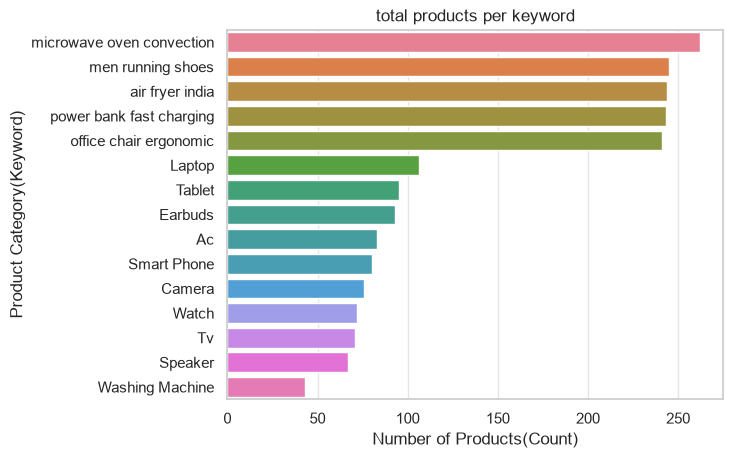

In [15]:
# 1. How many total products are available per keyword?

keyword_count=pro_df['keyword'].value_counts().reset_index()

sns.barplot(data=keyword_count,
            x='count',
            y='keyword',
            hue='keyword')

plt.xlabel("Number of Products(Count)")
plt.ylabel("Product Category(Keyword)")
plt.title("total products per keyword")
plt.show()

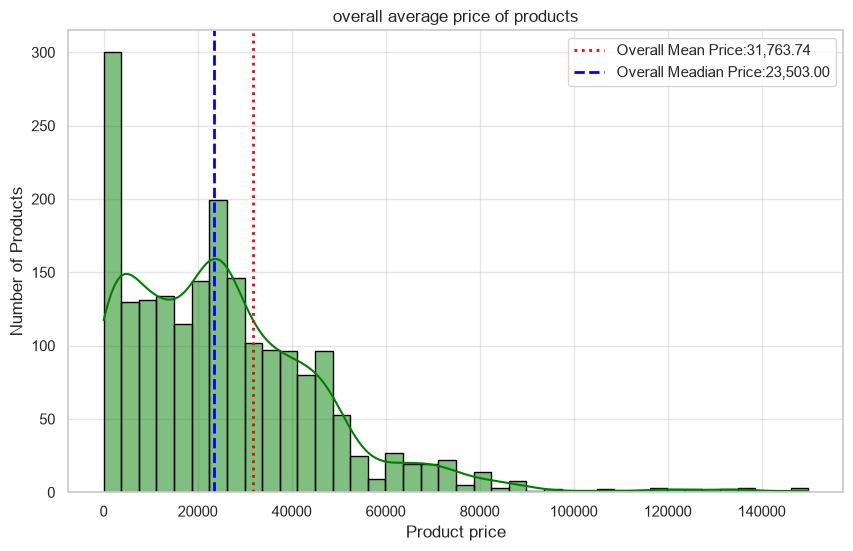

In [16]:
# 2.What is the overall average price of products?

mean_price=pro_df['price'].mean()
median_price=pro_df['price'].median()

vis_df=pro_df[pro_df['price']<=150000]

sns.set_theme(style="whitegrid")
fig, ax=plt.subplots(figsize=(10,6))


sns.histplot(data=vis_df,
             x='price',
             kde=True,
             bins=40,
             color='green',
             edgecolor='black',
             ax=ax)

ax.axvline(mean_price,
            color='red',
            linestyle='dotted',
            linewidth=2,
            label=f"Overall Mean Price:{mean_price:,.2f}")

ax.axvline(median_price,
            color='blue',
            linestyle='dashed',
            linewidth=2,
            label=f"Overall Meadian Price:{median_price:,.2f}")

ax.set_title("overall average price of products")
ax.set_xlabel("Product price")
ax.set_ylabel("Number of Products")
ax.legend()
plt.show()

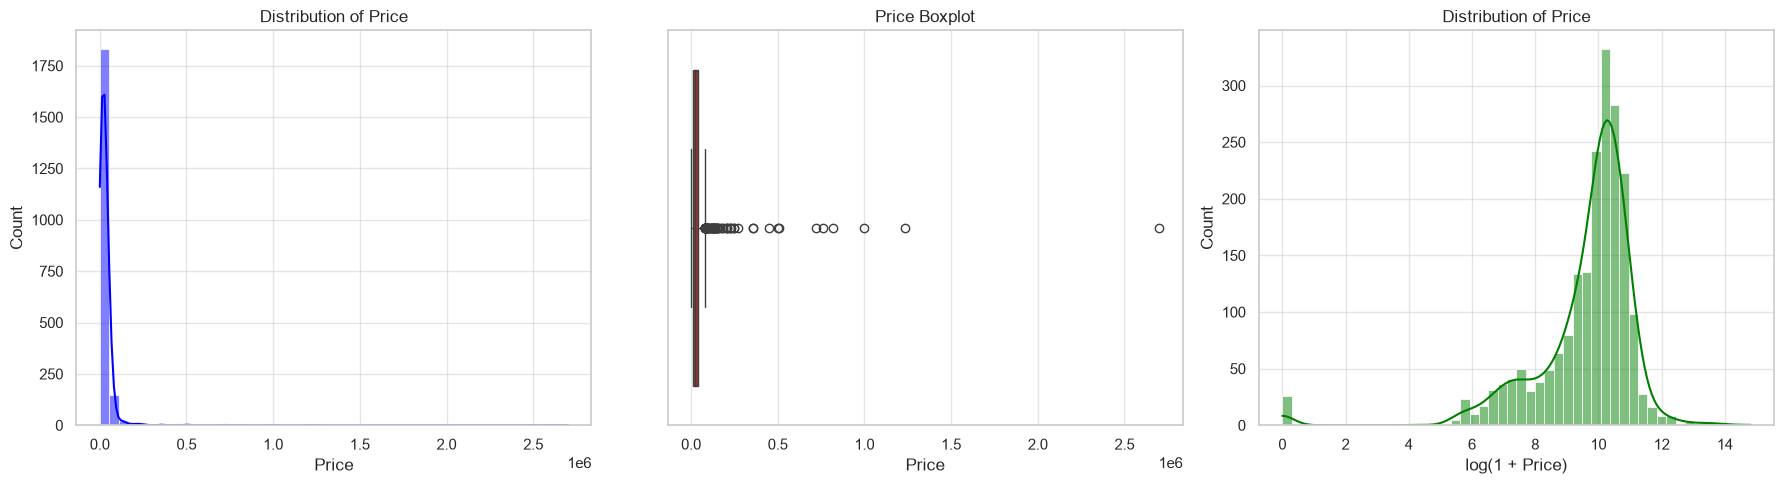

In [42]:
# 3.What is the distribution of price across all products?

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


sns.histplot(pro_df['price'],
             bins=50,
             kde=True,
             ax=axes[0],
             color='blue')
axes[0].set_title('Distribution of Price')
axes[0].set_xlabel('Price')


sns.boxplot(x=pro_df['price'],
            ax=axes[1],
            color='brown')
axes[1].set_title('Price Boxplot')
axes[1].set_xlabel('Price')


sns.histplot(np.log1p(pro_df['price']),
             bins=50,
             kde=True,
             ax=axes[2],
             color='green')
axes[2].set_title('Distribution of Price')
axes[2].set_xlabel('log(1 + Price)')

plt.tight_layout()
plt.show()

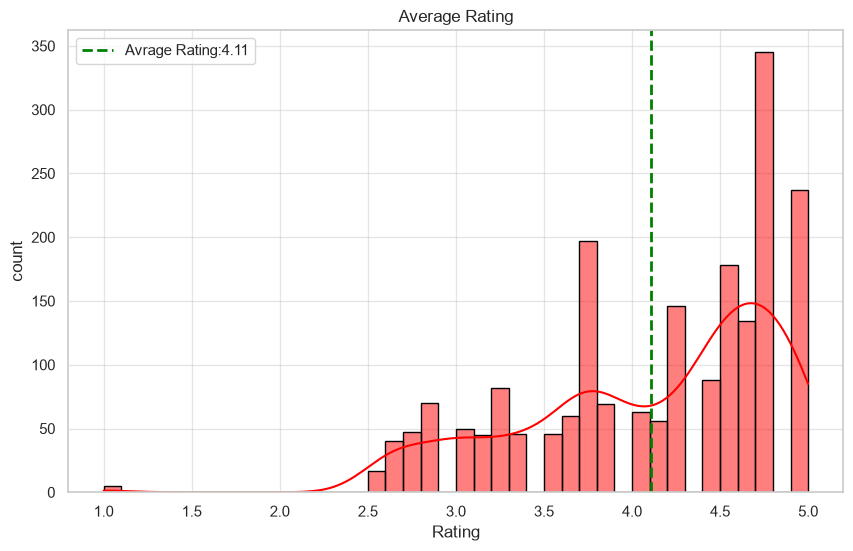

Avrage Rating: 4.107026224641267


In [47]:
# 4.What is the average rating across all products?

avg_rating=pro_df['rating'].mean()

fig,ax=plt.subplots(figsize=(10,6))

sns.histplot(data=pro_df['rating'],
             bins=40,
             kde=True,
             color='red',
             edgecolor='black')
ax.axvline(avg_rating,
           color='green',
           linestyle='dashed',
           linewidth=2,
           label=f"Avrage Rating:{avg_rating:.2f}")

ax.set_title("Average Rating")
ax.set_xlabel("Rating")
ax.set_ylabel("count")
ax.legend()
plt.show()

print("Avrage Rating:",avg_rating)

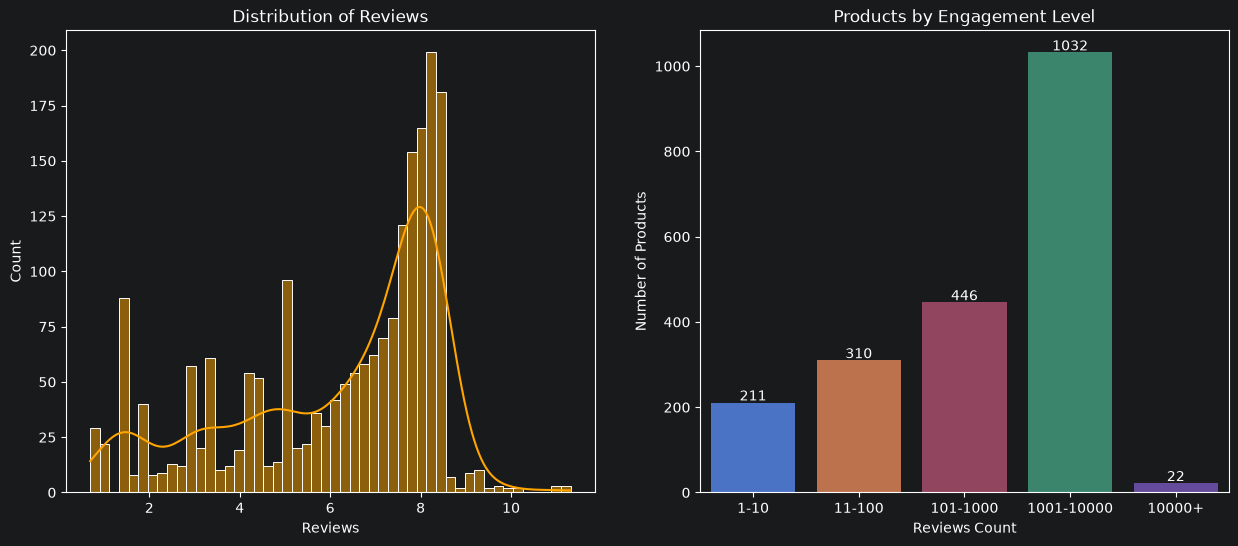

In [9]:
# 5. How are reviews distributed (low vs high engagement products)?

bins=[0,10,100,1000,10000,100000]
labels=['1-10', '11-100', '101-1000', '1001-10000', '10000+']
pro_df['engagement']=pd.cut(pro_df['reviews'],bins=bins,labels=labels)

fig,ax=plt.subplots(1,2,figsize=(15,6))

sns.histplot(np.log1p(pro_df['reviews']),
             bins=50,
             kde=True,
             color='orange',
             edgecolor='white',
             ax=ax[0])
ax[0].set_title("Distribution of Reviews")
ax[0].set_xlabel("Reviews")
ax[0].set_ylabel("Count")

bucket_count=pro_df['engagement'].value_counts().reindex(labels)
sns.barplot(x=bucket_count.index,
            y=bucket_count.values,
            hue=bucket_count.index,
            legend=False,
            ax=ax[1])
ax[1].set_title("Products by Engagement Level")
ax[1].set_xlabel("Reviews Count")
ax[1].set_ylabel("Number of Products")

for i, v in enumerate(bucket_count.values):
    ax[1].text(i, v + 5, str(v), ha='center')

plt.show()


In [ ]:
# Brand Analysis

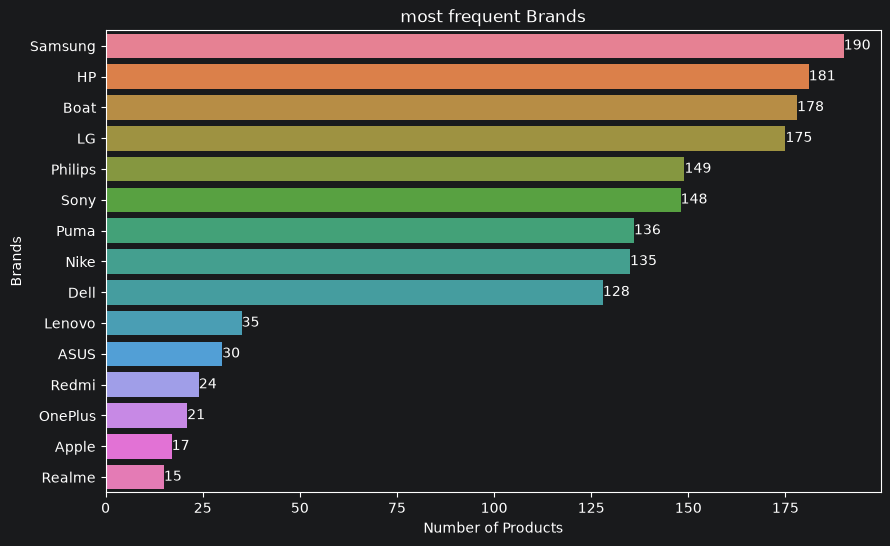

In [19]:
# 6.Which brand appears most frequently?

pro_df['brand']=pro_df['title'].str.strip().str.split().str[0]

pro_df['brand_nor']=pro_df['brand'].str.lower()
display_map=pro_df.groupby('brand_nor')['brand'].agg(lambda x: x.value_counts().idxmax())
brand_counts=pro_df['brand_nor'].value_counts().head(15)
brand_counts.index=brand_counts.index.map(display_map)

fig,ax=plt.subplots(figsize=(10,6))
sns.barplot(x=brand_counts.values,
            y=brand_counts.index,
            hue=brand_counts.index,
            legend=False,
            ax=ax)
ax.set_title("most frequent Brands")
ax.set_ylabel("Brands")
ax.set_xlabel("Number of Products")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

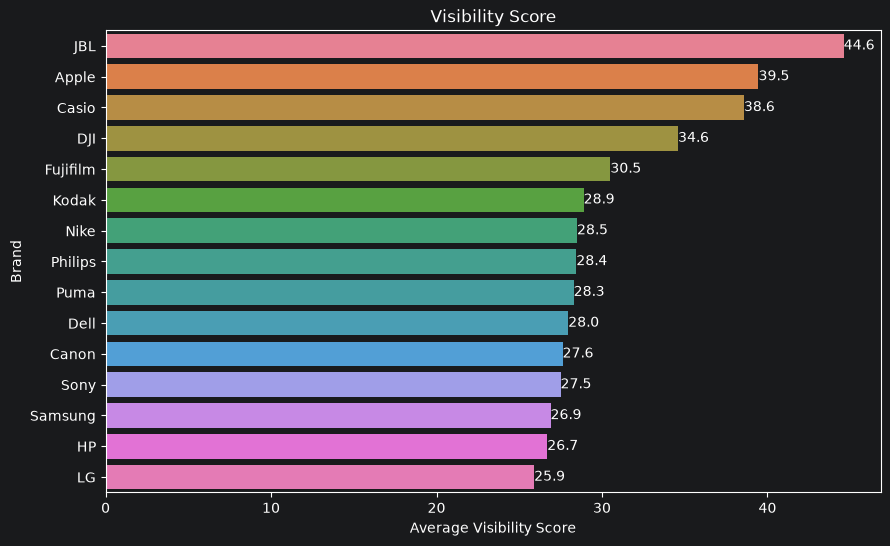

In [28]:
# 7.Which brand has the highest average visibility_score?

pro_df['visibility_score'] = pro_df['rating'] * np.log1p(pro_df['reviews'])

pro_df['brand'] = pro_df['title'].str.strip().str.split().str[0]
pro_df['brand_norm'] = pro_df['brand'].str.lower()
display_map = pro_df.groupby('brand_norm')['brand'].agg(lambda x: x.value_counts().idxmax())

brand_stats = pro_df.groupby('brand_norm').agg(
    avg_visibility=('visibility_score', 'mean'),
    product_count=('visibility_score', 'count')
)
brand_stats = brand_stats[brand_stats['product_count'] >= 5]
brand_stats.index = brand_stats.index.map(display_map)
top_brands = brand_stats.sort_values('avg_visibility', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_brands['avg_visibility'],
            y=top_brands.index,
            hue=top_brands.index,
            legend=False,
            ax=ax)

ax.set_title('Visibility Score')
ax.set_xlabel('Average Visibility Score')
ax.set_ylabel('Brand')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')

plt.show()

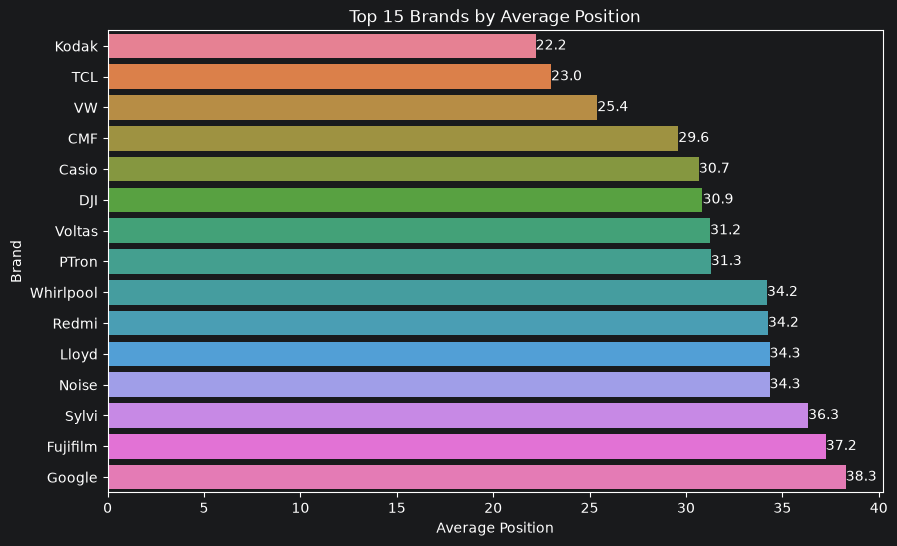

In [5]:
# 8. What is the average position (ranking) per brand?

pro_df['position'] = pro_df.groupby('keyword').cumcount() + 1

pro_df['brand'] = pro_df['title'].str.strip().str.split().str[0]
pro_df['brand_norm'] = pro_df['brand'].str.lower()
display_map = pro_df.groupby('brand_norm')['brand'].agg(lambda x: x.value_counts().idxmax())

counts = pro_df['brand_norm'].value_counts()
top_brands = counts[counts >= 5].index
plot_df = pro_df[pro_df['brand_norm'].isin(top_brands)]

avg_position = plot_df.groupby('brand_norm')['position'].mean().sort_values()
avg_position.index = avg_position.index.map(display_map)

fig,ax=plt.subplots(figsize=(10,6))
sns.barplot(x=avg_position.head(15).values,
            y=avg_position.head(15).index,
            hue=avg_position.head(15).index,
            legend=False,
            ax=ax)
ax.set_title('Top 15 Brands by Average Position')
ax.set_xlabel('Average Position')
ax.set_ylabel('Brand')
for i in ax.containers:
    ax.bar_label(i,fmt='%.1f')

plt.show()


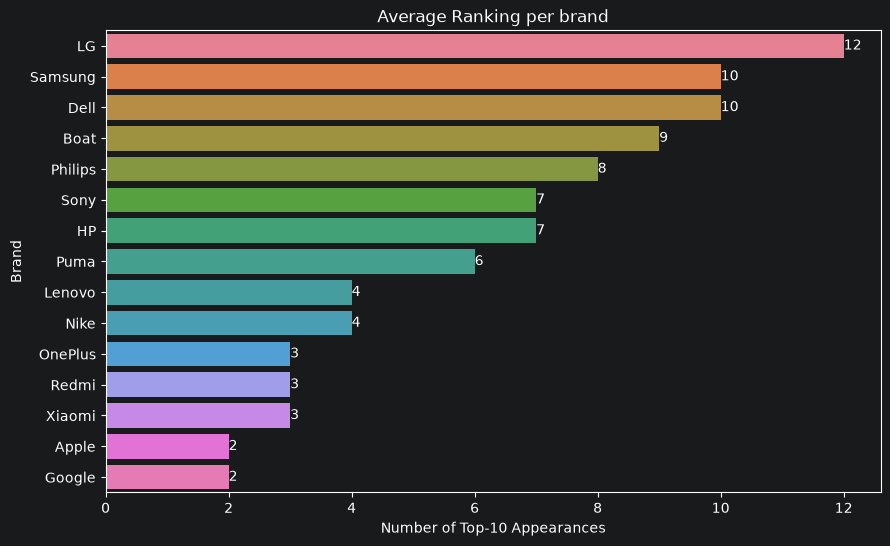

brand_nor
LG         12
Samsung    10
Dell       10
Boat        9
Philips     8
Sony        7
HP          7
Puma        6
Lenovo      4
Nike        4
OnePlus     3
Redmi       3
Xiaomi      3
Apple       2
Google      2
Name: count, dtype: int64


In [38]:
# 9. Which brands appear most in top 10 positions (position <= 10)?

pro_df['position']=pro_df.groupby('keyword').cumcount()+1

pro_df['brand']=pro_df['title'].str.strip().str.split().str[0]
pro_df['brand_nor']=pro_df['brand'].str.lower()
display_map=pro_df.groupby('brand_nor')['brand'].agg(lambda x: x.value_counts().idxmax())

top10=pro_df[pro_df['position']<=10]
top10_counts=top10['brand_nor'].value_counts().head(15)
top10_counts.index=top10_counts.index.map(display_map)

fig,ax=plt.subplots(figsize=(10,6))
sns.barplot(x=top10_counts.values,
            y=top10_counts.index,
            hue=top10_counts.index,
            legend=False,
            ax=ax)

ax.set_title('Average Ranking per brand')
ax.set_xlabel('Number of Top-10 Appearances')
ax.set_ylabel('Brand')

for container in ax.containers:
    ax.bar_label(container)

plt.show()
print(top10_counts)

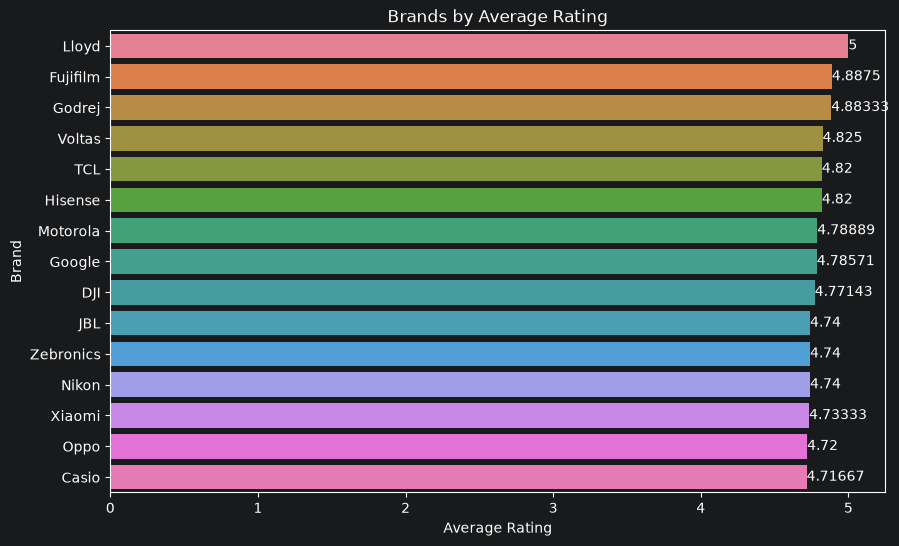

            avg_rating  product_count
brand_norm                           
Lloyd         5.000000              6
Fujifilm      4.887500              8
Godrej        4.883333             12
Voltas        4.825000             12
TCL           4.820000              5
Hisense       4.820000              5
Motorola      4.788889              9
Google        4.785714              7
DJI           4.771429              7
JBL           4.740000              5
Zebronics     4.740000             10
Nikon         4.740000              5
Xiaomi        4.733333             12
Oppo          4.720000             10
Casio         4.716667              6


In [42]:
# 10. . Which brands have the highest average rating?

pro_df['brand']=pro_df['title'].str.strip().str.split().str[0]
pro_df['brand_norm']=pro_df['brand'].str.lower()
display_map=pro_df.groupby('brand_norm')['brand'].agg(lambda x: x.value_counts().idxmax())

brand_stats=pro_df.groupby('brand_norm').agg(
    avg_rating=('rating', 'mean'),
    product_count=('rating', 'count')
)
brand_stats=brand_stats[brand_stats['product_count'] >= 5]
brand_stats.index=brand_stats.index.map(display_map)
top_brands=brand_stats.sort_values('avg_rating', ascending=False).head(15)

fig,ax=plt.subplots(figsize=(10, 6))
sns.barplot(x=top_brands['avg_rating'],
            y=top_brands.index,
            hue=top_brands.index,
            legend=False,
            ax=ax)

ax.set_title('Brands by Average Rating')
ax.set_xlabel('Average Rating')
ax.set_ylabel('Brand')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

print(top_brands)

In [ ]:
# Pricing Analysis

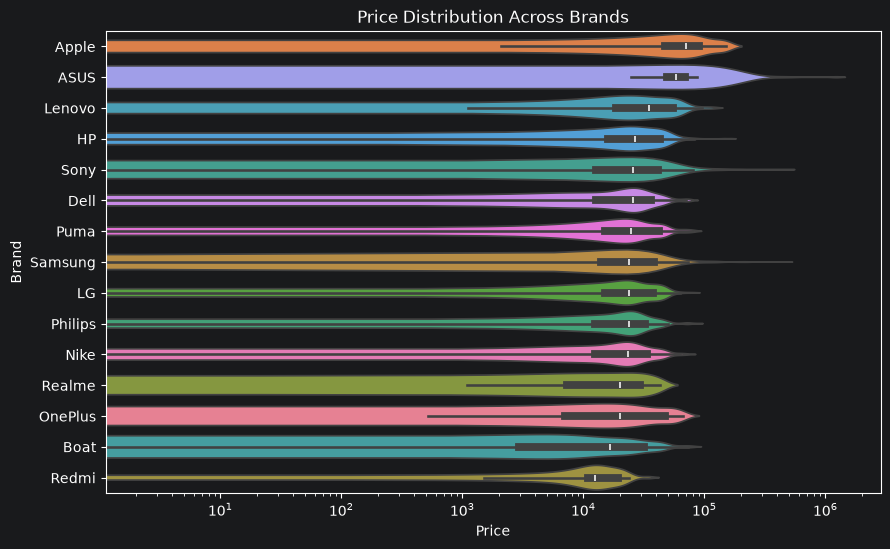

In [5]:
# 11.  What is the price distribution across different brands?

pro_df['brand']=pro_df['title'].str.strip().str.split().str[0]
pro_df['brand_nor']=pro_df['brand'].str.upper()
display_map=pro_df.groupby('brand_nor')['brand'].agg(lambda x: x.value_counts().idxmax())
pro_df['brand_display']=pro_df['brand_nor'].map(display_map)

counts=pro_df['brand_nor'].value_counts()
top_brand=counts[counts>=15].index
plot_df=pro_df[pro_df['brand_nor'].isin(top_brand)].copy()

order=plot_df.groupby('brand_display')['price'].median().sort_values(ascending=False).index

fig,ax=plt.subplots(figsize=(10,6))
sns.violinplot(data=plot_df,
               x='price',
               y='brand_display',
               order=order,
               hue='brand_display',
               legend=False,
               ax=ax)
ax.set_xscale('log')
ax.set_title("Price Distribution Across Brands")
ax.set_xlabel("Price")
ax.set_ylabel("Brand")

plt.show()

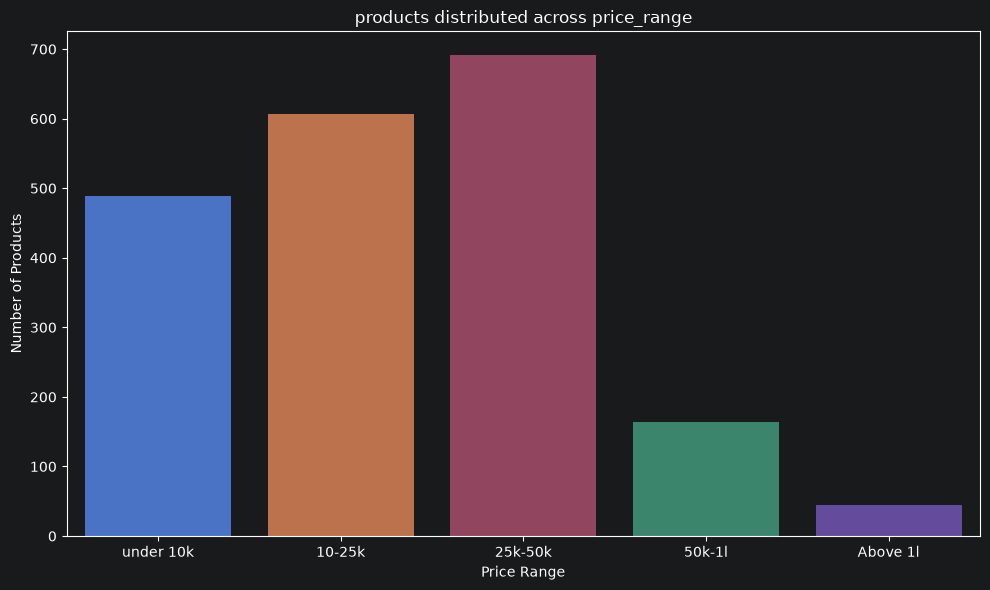

In [6]:
# 12. How are products distributed across price_range categories?

bins=[0,10000,25000,50000,100000,float('inf')]
labels=['under 10k','10-25k','25k-50k','50k-1l','Above 1l']
pro_df['price_range']=pd.cut(pro_df['price'],bins,labels=labels)

range_counts=pro_df['price_range'].value_counts().reindex(labels)

fig,ax=plt.subplots(figsize=(10,6))
sns.barplot(x=range_counts.index,
            y=range_counts.values,
            hue=range_counts.index,
            legend=False,
            ax=ax)
ax.set_title("products distributed across price_range")
ax.set_xlabel("Price Range")
ax.set_ylabel("Number of Products")

plt.tight_layout()
plt.show()

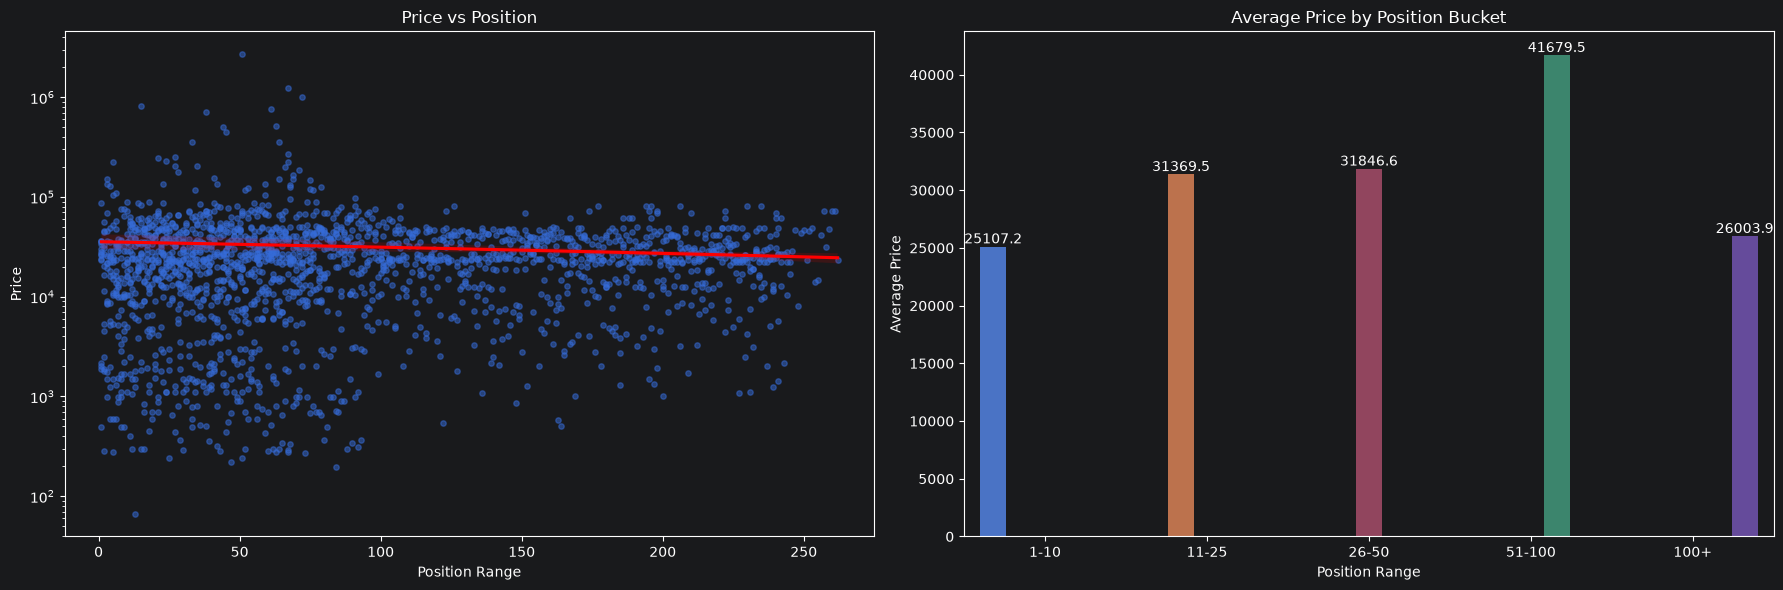

In [13]:
# 13.Do higher-priced products have better rankings (position)?

pro_df['position']=pro_df.groupby('keyword').cumcount()+1

fig,ax=plt.subplots(1,2,figsize=(18,6))

sns.regplot(data=pro_df,
            x='position',
            y='price',
            scatter_kws={'alpha':0.5,'s':15},
            line_kws={'color':'red'},
            ax=ax[0]
            )
ax[0].set_yscale('log')
ax[0].set_title("Price vs Position")
ax[0].set_xlabel("Position Range")
ax[0].set_ylabel("Price")


pro_df['pos_bucket'] = pd.cut(pro_df['position'],
                          bins=[0, 10, 25, 50, 100, 300],
                          labels=['1-10', '11-25', '26-50', '51-100', '100+'])

avg_price_by_bucket = pro_df.groupby('pos_bucket', observed=True)['price'].mean()
sns.barplot(x=avg_price_by_bucket.index,
            y=avg_price_by_bucket.values,
            hue=avg_price_by_bucket.index,
            legend=False,
            ax=ax[1])
ax[1].set_title("Average Price by Position Bucket")
ax[1].set_xlabel("Position Range")
ax[1].set_ylabel("Average Price")

for container in ax[1].containers:
    ax[1].bar_label(container)

plt.tight_layout()
plt.show()

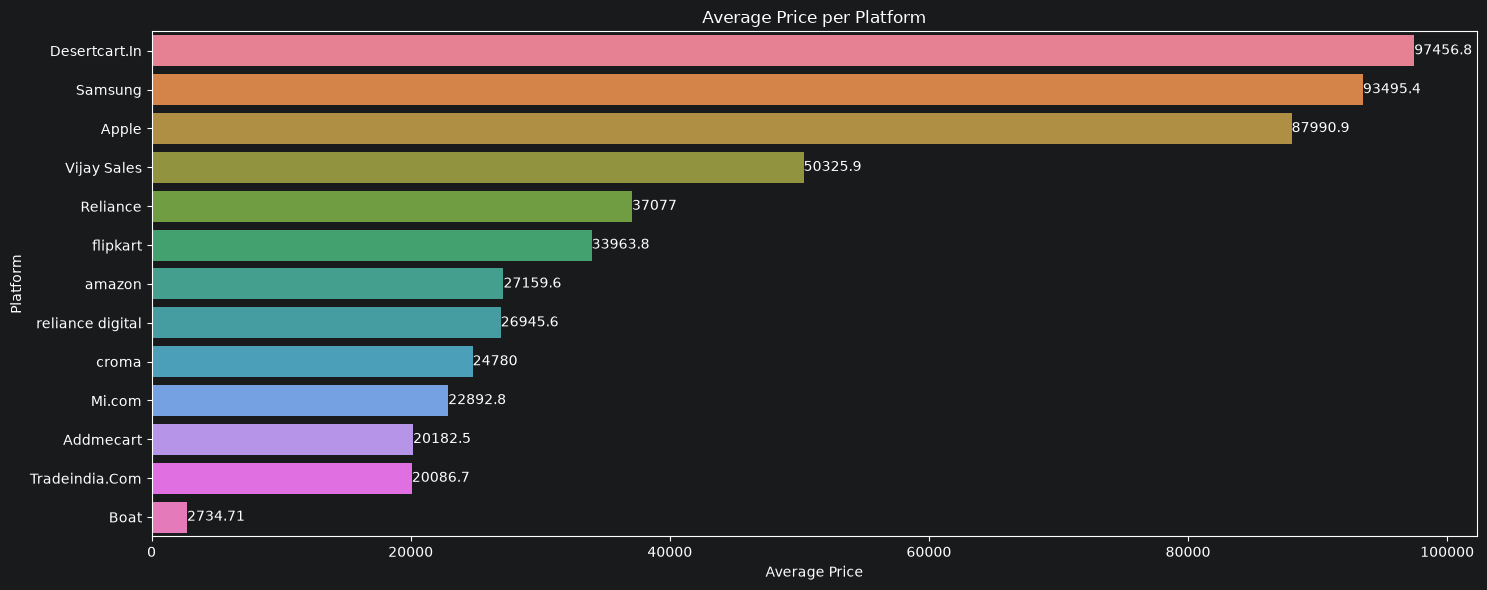

platform_display
Desertcart.In       97456.846154
Samsung             93495.400000
Apple               87990.909091
Vijay Sales         50325.909091
Reliance            37077.023134
flipkart            33963.768301
amazon              27159.557295
reliance digital    26945.633519
croma               24780.007862
Mi.com              22892.750000
Addmecart           20182.470588
Tradeindia.Com      20086.672500
Boat                 2734.714286
Name: price, dtype: float64


In [16]:
# 14.What is the average price per platform?

pro_df['platform_norm']=pro_df['platform'].str.strip().str.lower()
display_map=pro_df.groupby('platform_norm')['platform'].agg(lambda x: x.value_counts().idxmax())
pro_df['platform_display']=pro_df['platform_norm'].map(display_map)

counts=pro_df['platform_norm'].value_counts()
top_platforms=counts[counts >= 10].index
plot_df=pro_df[pro_df['platform_norm'].isin(top_platforms)]

avg_price = plot_df.groupby('platform_display')['price'].mean().sort_values(ascending=False)

fig,ax=plt.subplots(figsize=(15,6))
sns.barplot(x=avg_price.values,
            y=avg_price.index,
            hue=avg_price.index,
            legend=False,
            ax=ax)

ax.set_title('Average Price per Platform')
ax.set_xlabel('Average Price')
ax.set_ylabel('Platform')
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

print(avg_price)

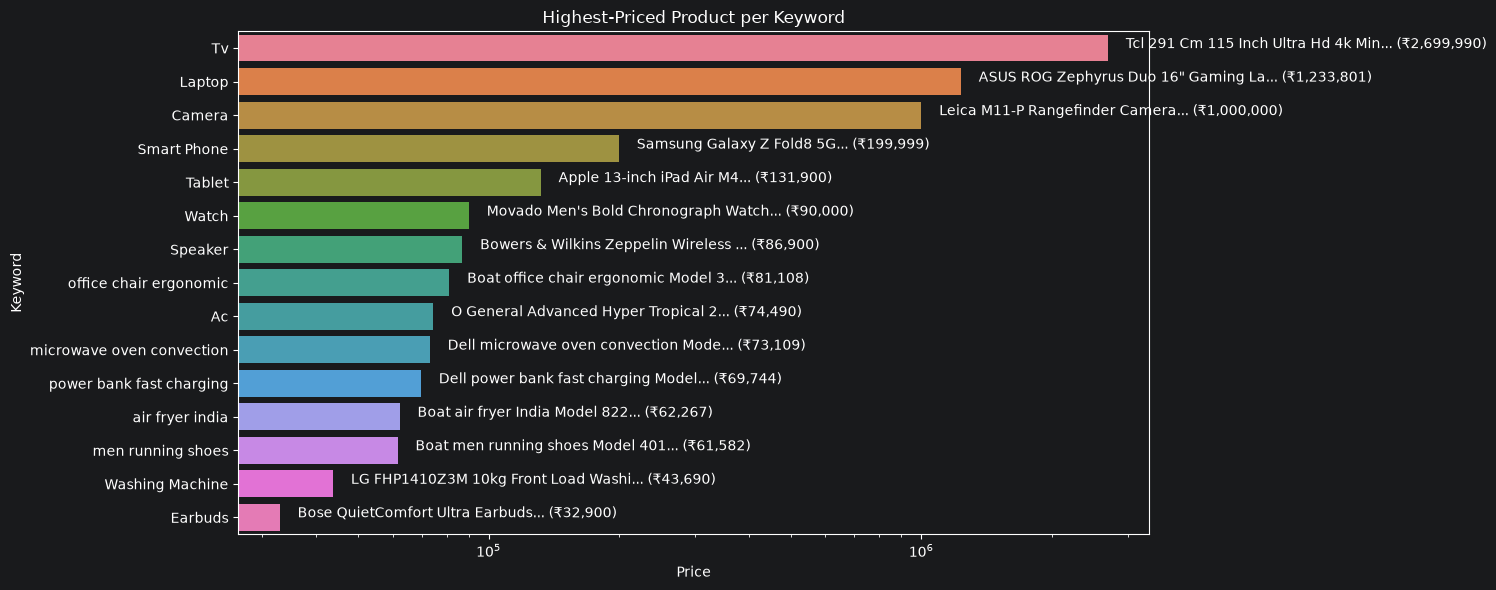

In [20]:
# 15. Which products have the highest price within each keyword?

idx= pro_df.groupby('keyword')['price'].idxmax()
top=pro_df.loc[idx,['keyword','title','price']].sort_values('price', ascending=False)
top['short_title']=top['title'].str.slice(0, 35) + '...'

fig,ax=plt.subplots(figsize=(15,6))
sns.barplot(data=top,
            x='price',
            y='keyword',
            hue='keyword',
            legend=False,
            ax=ax)

ax.set_xscale('log')
ax.set_title('Highest-Priced Product per Keyword')
ax.set_xlabel('Price')
ax.set_ylabel('Keyword')

for i, (p, t) in enumerate(zip(top['price'], top['short_title'])):
    ax.text(p * 1.1, i, f'{t} (₹{p:,.0f})')
plt.tight_layout()
plt.show()


In [ ]:
# Platform Analysis

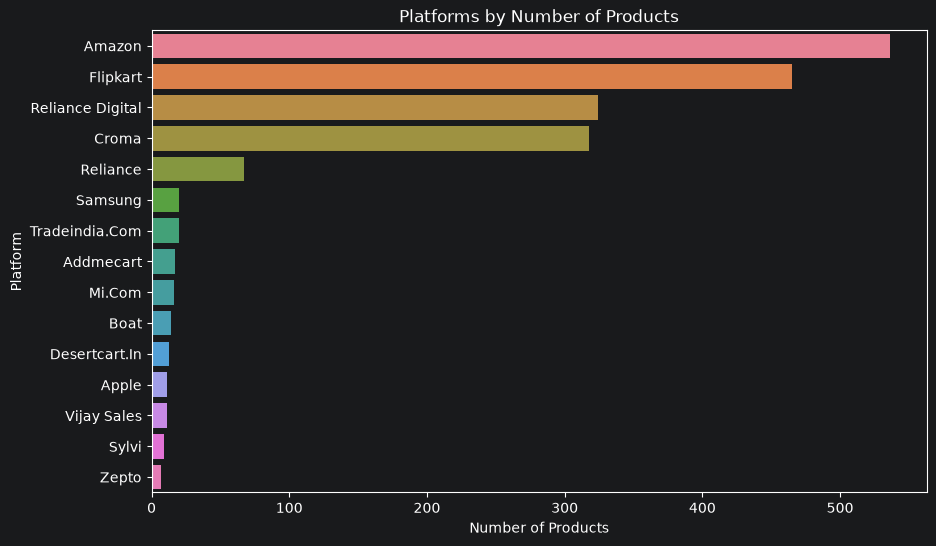

In [4]:
# 21. Which platform lists the highest number of products?

pro_df['platform_norm']=pro_df['platform'].str.strip().str.lower()

platform_counts=pro_df['platform_norm'].value_counts().head(15)
platform_counts.index=platform_counts.index.str.title()

fig,ax=plt.subplots(figsize=(10,6))
sns.barplot(x=platform_counts.values,
            y=platform_counts.index,
            hue=platform_counts.index,
            legend=False,
            ax=ax)
ax.set_title("Platforms by Number of Products")
ax.set_xlabel("Number of Products")
ax.set_ylabel("Platform")

plt.show()

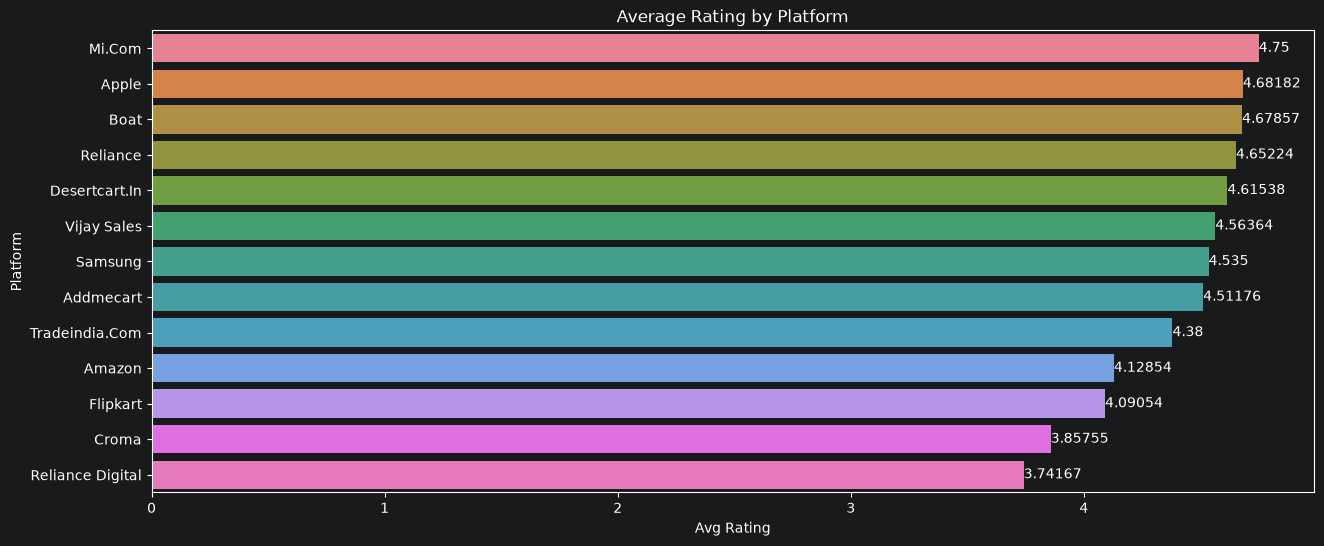

In [7]:
# 22. Which platform has the highest average rating?

pro_df['platform_norm']=pro_df['platform'].str.strip().str.lower()

counts=pro_df['platform_norm'].value_counts()
top_platforms=counts[counts>=10].index
plot_df=pro_df[pro_df['platform_norm'].isin(top_platforms)]

avg_rating=plot_df.groupby('platform_norm')['rating'].mean().sort_values(ascending=False)
avg_rating.index=avg_rating.index.str.title()

fig,ax=plt.subplots(figsize=(15,6))
sns.barplot(x=avg_rating.values,
            y=avg_rating.index,
            hue=avg_rating.index,
            legend=False,
            ax=ax)
ax.set_title("Average Rating by Platform")
ax.set_xlabel("Avg Rating")
ax.set_ylabel("Platform")

for i in ax.containers:
    ax.bar_label(i)

plt.show()

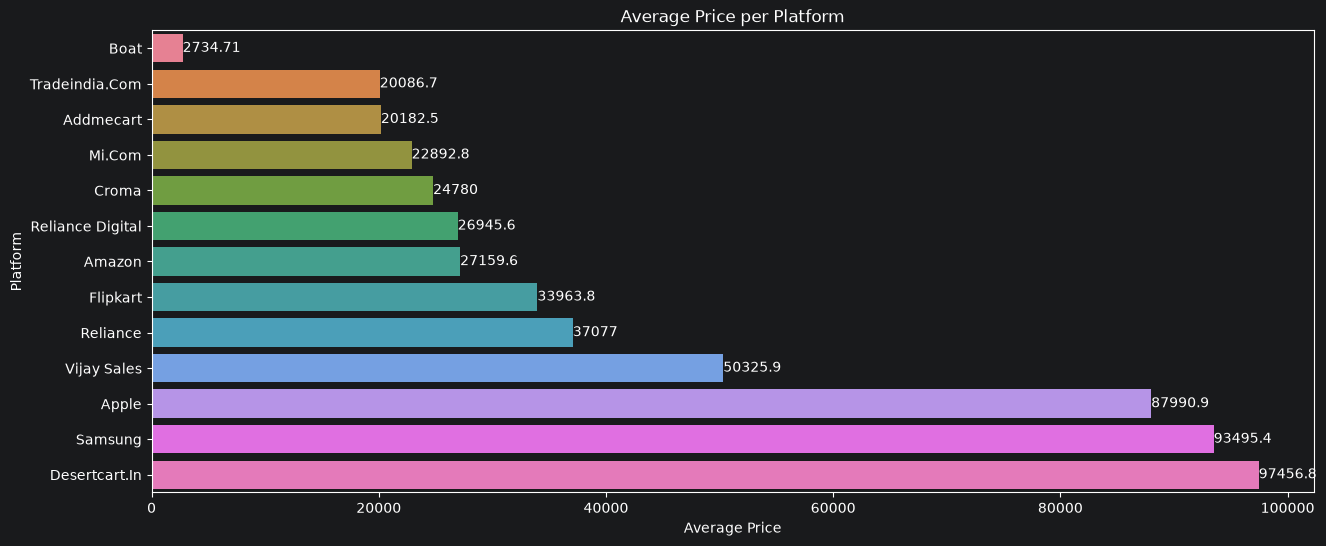

In [15]:
# 23. Which platform has the lowest average price?

pro_df['platform_norm'] = pro_df['platform'].str.strip().str.lower()

counts = pro_df['platform_norm'].value_counts()
top_platforms = counts[counts >= 10].index
plot_df = pro_df[pro_df['platform_norm'].isin(top_platforms)]

avg_price = plot_df.groupby('platform_norm')['price'].mean().sort_values()
avg_price.index = avg_price.index.str.title()

fig, ax = plt.subplots(figsize=(15, 6))
sns.barplot(x=avg_price.values,
            y=avg_price.index,
            hue=avg_price.index,
            legend=False,
            ax=ax)

ax.set_title('Average Price per Platform')
ax.set_xlabel('Average Price')
ax.set_ylabel('Platform')
for i in ax.containers:
    ax.bar_label(i)

plt.show()

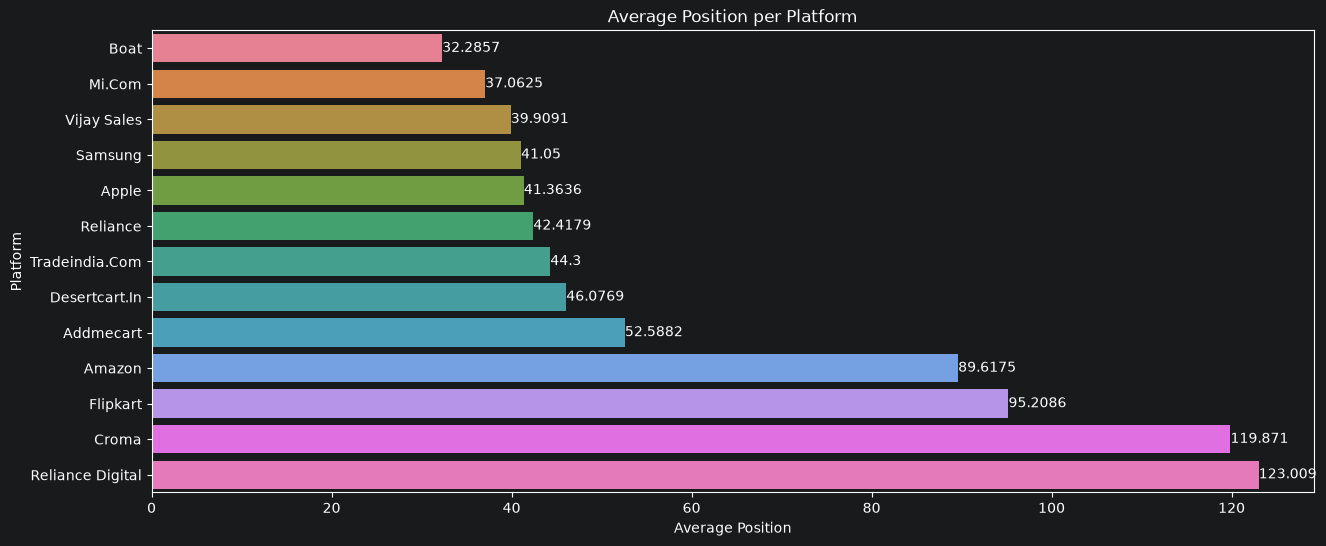

 rank         platform  avg_position
    1             Boat     32.285714
    2           Mi.Com     37.062500
    3      Vijay Sales     39.909091
    4          Samsung     41.050000
    5            Apple     41.363636
    6         Reliance     42.417910
    7   Tradeindia.Com     44.300000
    8    Desertcart.In     46.076923
    9        Addmecart     52.588235
   10           Amazon     89.617537
   11         Flipkart     95.208602
   12            Croma    119.871069
   13 Reliance Digital    123.009259


In [18]:
# 24. What is the average position (ranking) per platform?

pro_df['position']=pro_df.groupby('keyword').cumcount() + 1
pro_df['platform_norm']=pro_df['platform'].str.strip().str.lower()

counts=pro_df['platform_norm'].value_counts()
top_platforms=counts[counts >= 10].index
plot_df=pro_df[pro_df['platform_norm'].isin(top_platforms)]

avg_position=plot_df.groupby('platform_norm')['position'].mean().sort_values()
avg_position.index=avg_position.index.str.title()

fig,ax=plt.subplots(figsize=(15,6))
sns.barplot(x=avg_position.values,
            y=avg_position.index,
            hue=avg_position.index,
            legend=False,
            ax=ax)

ax.set_title('Average Position per Platform')
ax.set_xlabel('Average Position')
ax.set_ylabel('Platform')

for i in ax.containers:
    ax.bar_label(i)

plt.show()

rank_table=avg_position.reset_index()
rank_table.columns=['platform', 'avg_position']
rank_table.insert(0,'rank',range(1,len(rank_table)+1))

print(rank_table.to_string(index=False))

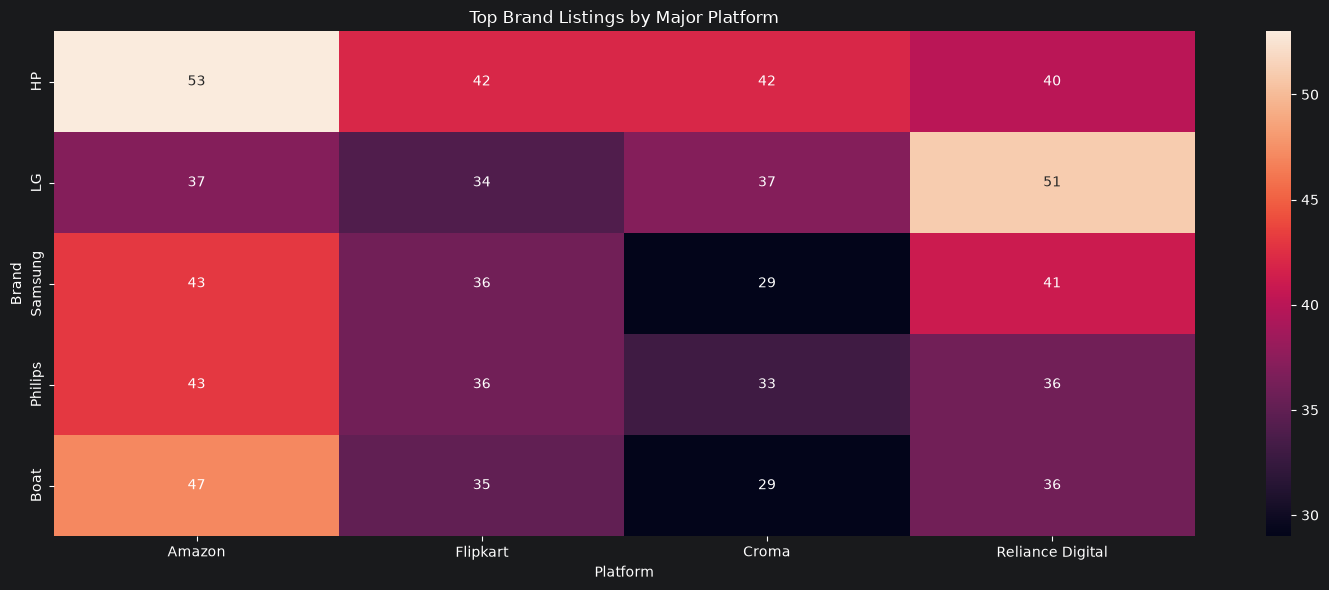

In [23]:
# 25. Which brands are most frequently listed on each platform?

pro_df['brand']=pro_df['title'].str.strip().str.split().str[0]
pro_df['brand_norm']=pro_df['brand'].str.lower()
display_map=pro_df.groupby('brand_norm')['brand'].agg(lambda x: x.value_counts().idxmax())
pro_df['brand_display']=pro_df['brand_norm'].map(display_map)

pro_df['platform_display']=pro_df['platform'].str.strip().str.lower().str.title()

major_platforms=['Amazon','Flipkart','Croma','Reliance Digital']
plot_df=pro_df[pro_df['platform_display'].isin(major_platforms)]

top_brands=plot_df['brand_display'].value_counts().head(5).index
plot_df2=plot_df[plot_df['brand_display'].isin(top_brands)]

pivot=pd.crosstab(plot_df2['brand_display'], plot_df2['platform_display'])[major_platforms]
pivot=pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

fig,ax=plt.subplots(figsize=(15, 6))
sns.heatmap(pivot,
            annot=True,
            ax=ax)

ax.set_title('Top Brand Listings by Major Platform')
ax.set_xlabel('Platform')
ax.set_ylabel('Brand')
plt.tight_layout()
plt.show()

In [ ]:
# Visibility & Ranking Analysis

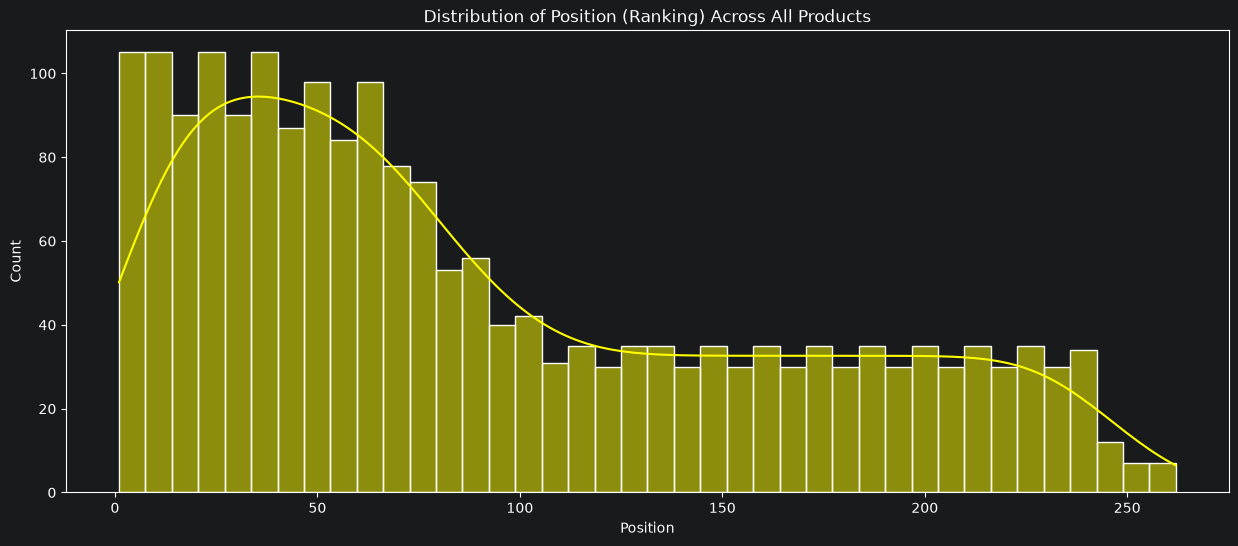

count    2021.000000
mean       92.007422
std        70.688870
min         1.000000
25%        34.000000
50%        70.000000
75%       146.000000
max       262.000000
Name: position, dtype: float64


In [28]:
# 26.  What is the distribution of position (ranking)?

pro_df['position']=pro_df.groupby('keyword').cumcount() + 1

fig,ax =plt.subplots(figsize=(15,6))
sns.histplot(pro_df['position'],
             bins=40,
             kde=True,
             color='yellow',
             edgecolor='white',
             ax=ax)

ax.set_title('Distribution of Position (Ranking) Across All Products')
ax.set_xlabel('Position')
ax.set_ylabel('Count')

plt.show()

print(pro_df['position'].describe())

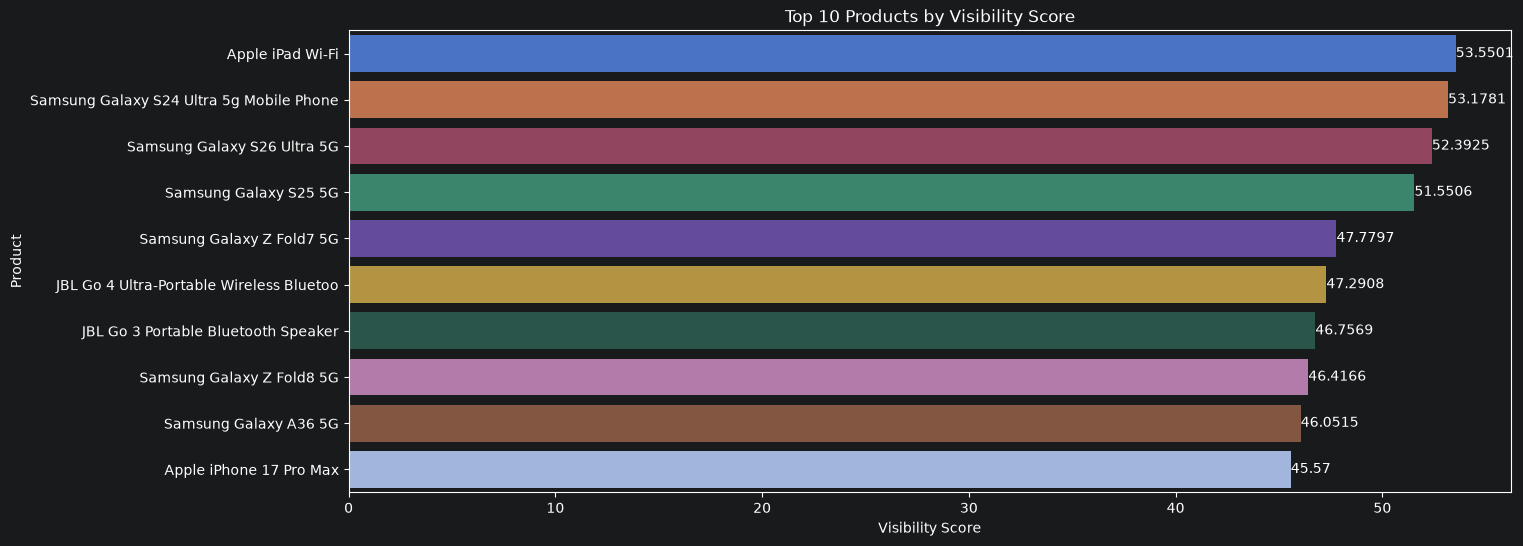

                                             title     keyword  rating  reviews  visibility_score
                                  Apple iPad Wi-Fi      Tablet     4.8    70000         53.550071
          Samsung Galaxy S24 Ultra 5g Mobile Phone Smart Phone     4.7    82000         53.178088
                       Samsung Galaxy S26 Ultra 5G Smart Phone     4.8    55000         52.392512
                             Samsung Galaxy S25 5G Smart Phone     4.7    58000         51.550613
                         Samsung Galaxy Z Fold7 5G Smart Phone     4.7    26000         47.779684
JBL Go 4 Ultra-Portable Wireless Bluetooth Speaker     Speaker     4.8    19000         47.290785
               JBL Go 3 Portable Bluetooth Speaker     Speaker     4.8    17000         46.756932
                         Samsung Galaxy Z Fold8 5G Smart Phone     4.9    13000         46.416630
                             Samsung Galaxy A36 5G Smart Phone     4.7    18000         46.051458
                    

In [31]:
# 27.Which products have the highest visibility_score?

pro_df['visibility_score']=pro_df['rating']*np.log1p(pro_df['reviews'])

df_dedup=pro_df.drop_duplicates(subset=['title','keyword','rating','reviews'])
top = df_dedup.sort_values('visibility_score', ascending=False).head(10)
top['short_title']=top['title'].str.slice(0,40)

fig,ax=plt.subplots(figsize=(15, 6))
sns.barplot(data=top,
            x='visibility_score',
            y='short_title',
            hue='short_title',
            legend=False,
            ax=ax)

ax.set_title('Top 10 Products by Visibility Score')
ax.set_xlabel('Visibility Score')
ax.set_ylabel('Product')
for i in ax.containers:
    ax.bar_label(i)

plt.show()

print(top[['title', 'keyword', 'rating', 'reviews', 'visibility_score']].to_string(index=False))

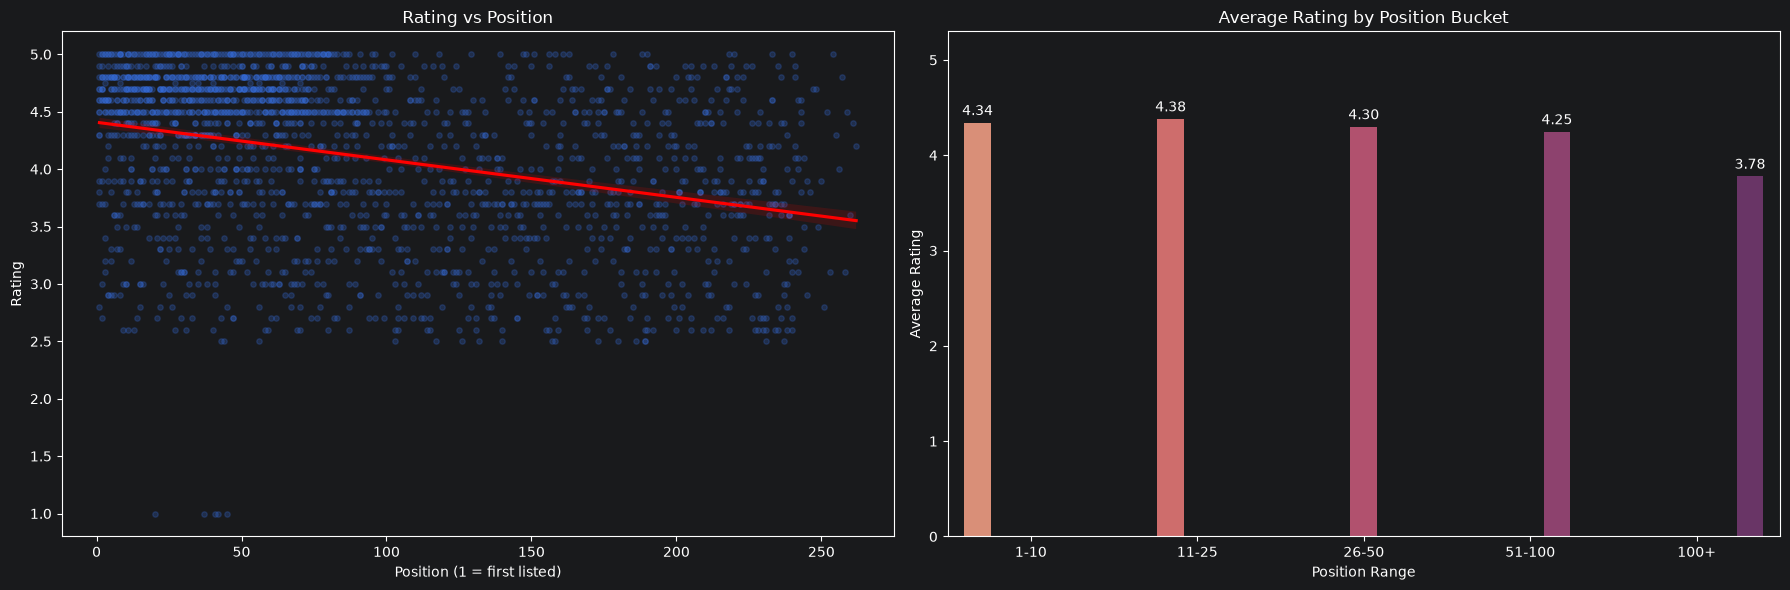

            rating  position
rating    1.000000 -0.324242
position -0.324242  1.000000


In [38]:
# 28. Is there a relationship between rating and position?

pro_df['position']=pro_df.groupby('keyword').cumcount()+1

fig,ax=plt.subplots(1,2,figsize=(18,6))

sns.regplot(data=pro_df,
            x='position',
            y='rating',
            scatter_kws={'alpha': 0.25,'s':15},
            line_kws={'color': 'red'},
            ax=ax[0])

ax[0].set_title('Rating vs Position')
ax[0].set_xlabel('Position (1 = first listed)')
ax[0].set_ylabel('Rating')

pro_df['pos_bucket'] = pd.cut(pro_df['position'], bins=[0, 10, 25, 50, 100, 300], labels=['1-10', '11-25', '26-50', '51-100', '100+'])
avg_rating_by_bucket = pro_df.groupby('pos_bucket', observed=True)['rating'].mean()
sns.barplot(x=avg_rating_by_bucket.index,
            y=avg_rating_by_bucket.values,
            hue=avg_rating_by_bucket.index,
            palette='flare',
            legend=False,
            ax=ax[1])

ax[1].set_title('Average Rating by Position Bucket')
ax[1].set_xlabel('Position Range')
ax[1].set_ylabel('Average Rating')
ax[1].set_ylim(0, 5.3)
for container in ax[1].containers:
    ax[1].bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

print(pro_df[['rating', 'position']].corr())

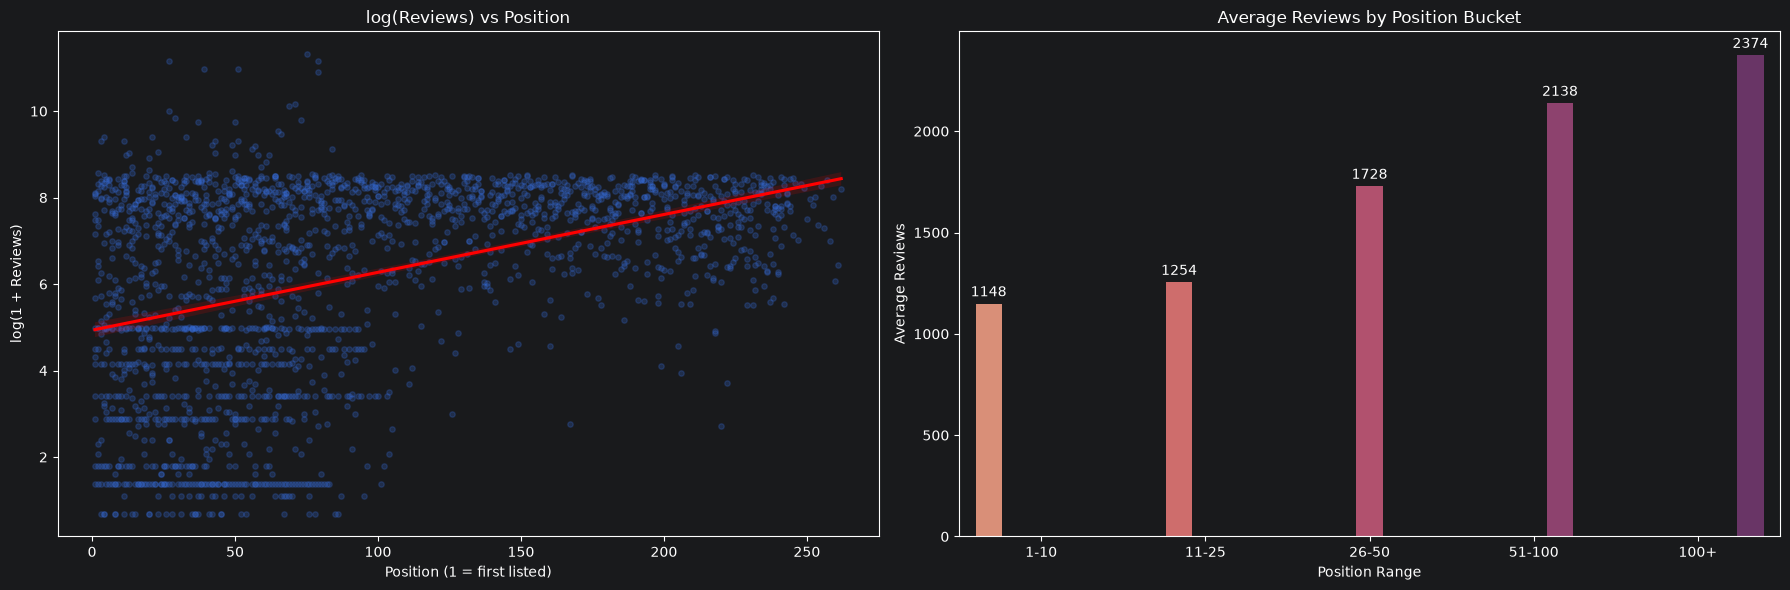

           reviews  position
reviews   1.000000  0.084469
position  0.084469  1.000000


In [40]:
# 29. Do products with higher reviews rank better?

pro_df['position']=pro_df.groupby('keyword').cumcount()+1

fig, ax = plt.subplots(1,2,figsize=(18,6))

sns.regplot(data=pro_df,
            x='position',
            y=np.log1p(pro_df['reviews']),
            scatter_kws={'alpha': 0.25, 's': 15},
            line_kws={'color': 'red'},
            ax=ax[0])

ax[0].set_title('log(Reviews) vs Position')
ax[0].set_xlabel('Position (1 = first listed)')
ax[0].set_ylabel('log(1 + Reviews)')


pro_df['pos_bucket'] = pd.cut(pro_df['position'], bins=[0, 10, 25, 50, 100, 300], labels=['1-10', '11-25', '26-50', '51-100', '100+'])
avg_reviews_by_bucket = pro_df.groupby('pos_bucket', observed=True)['reviews'].mean()
sns.barplot(x=avg_reviews_by_bucket.index,
            y=avg_reviews_by_bucket.values,
            hue=avg_reviews_by_bucket.index,
            palette='flare',
            legend=False,
            ax=ax[1])

ax[1].set_title('Average Reviews by Position Bucket')
ax[1].set_xlabel('Position Range')
ax[1].set_ylabel('Average Reviews')

for i in ax[1].containers:
    ax[1].bar_label(i, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()

print(pro_df[['reviews', 'position']].corr())

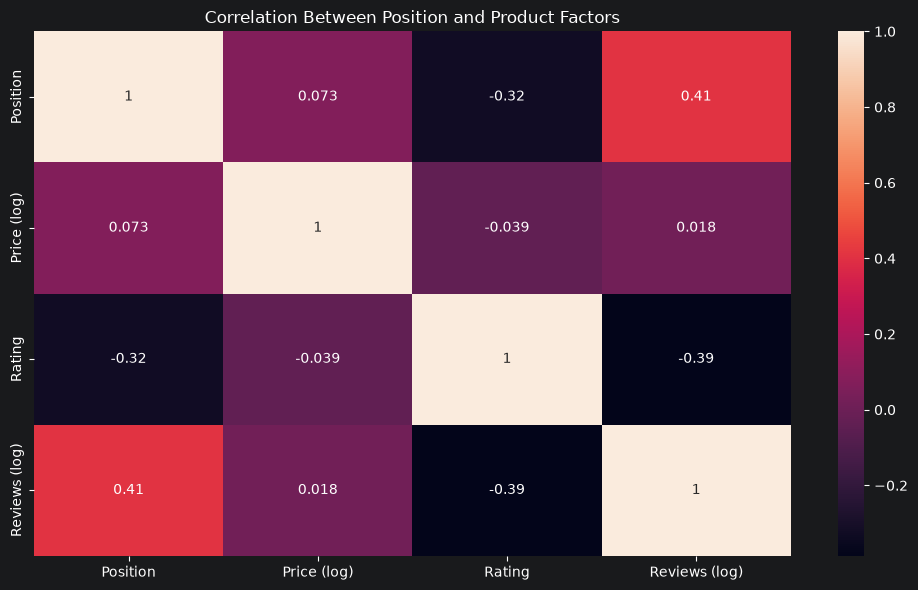

In [45]:
# 30. Which combination of factors (price, rating, reviews) influences top-ranking products?

pro_df['position'] = pro_df.groupby('keyword').cumcount() + 1
pro_df['log_reviews'] = np.log1p(pro_df['reviews'])
pro_df['log_price'] = np.log1p(pro_df['price'])


corr=pro_df[['position', 'log_price', 'rating', 'log_reviews']].corr()
corr.columns=['Position', 'Price (log)', 'Rating', 'Reviews (log)']
corr.index=corr.columns

fig,ax=plt.subplots(figsize=(10, 6))
sns.heatmap(corr,
            annot=True,
            ax=ax)

ax.set_title('Correlation Between Position and Product Factors')
plt.tight_layout()
plt.show()